FIXED OOD Evaluation: Norman (train) → Replogle (test)
=======================================================
Key fixes:
  1. Metrics computed ONLY on shared genes (not zero-padded full space)
  2. predict_ood uses encoded z from the actual cell (not random noise)
  3. Replogle ctrl_mean aligned properly; model uses Norman ctrl_mean for basal
  4. Per-condition aggregation before computing R² and Pearson (standard in GEARS/CPA)


In [10]:

import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import scanpy as sc
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Paths ──────────────────────────────────────────────────────────────────────
NORMAN_OUTPUT = '/content/drive/MyDrive/DL_Project_files/data/output'
DATA_DIR      = '/content/drive/MyDrive/DL_Project_files/data'
REPLOGE_PATH  = '/content/drive/MyDrive/DL_Project_files/data/output_reploge_local/replogle_k562.h5ad'
OOD_OUTPUT    = f'{NORMAN_OUTPUT}/ood_replogle'
os.makedirs(OOD_OUTPUT, exist_ok=True)

# ── Model definitions (unchanged) ─────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, dropout=0.1):
        super().__init__()
        dims   = [in_dim] + list(hidden_dims) + [out_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers += [nn.LayerNorm(dims[i+1]), nn.GELU(), nn.Dropout(dropout)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class PerturbationEncoder(nn.Module):
    def __init__(self, n_conditions, sem_dim=768, id_dim=64, cond_dim=128, dropout=0.1):
        super().__init__()
        self.id_embed = nn.Embedding(n_conditions, id_dim)
        self.fusion   = MLP(id_dim + sem_dim, [256, 256], cond_dim, dropout)
        self.act      = nn.GELU()

    def forward(self, cond_idx, sem_embed):
        id_vec   = self.id_embed(cond_idx)
        combined = torch.cat([id_vec, sem_embed], dim=-1)
        return self.act(self.fusion(combined))

class ExpressionEncoder(nn.Module):
    def __init__(self, n_genes, latent_dim=128, dropout=0.1):
        super().__init__()
        self.backbone  = MLP(n_genes, [512, 256], 256, dropout)
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        h = self.backbone(x)
        return self.fc_mu(h), self.fc_logvar(h)

class ExpressionDecoder(nn.Module):
    def __init__(self, n_genes, latent_dim=64, cond_dim=128, dropout=0.1):
        super().__init__()
        self.net = MLP(latent_dim + cond_dim, [256, 512], n_genes, dropout)

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=-1))

class KACVAE(nn.Module):
    def __init__(self, n_genes, n_conditions, sem_dim=768,
                 latent_dim=128, cond_dim=128, beta=1.0, dropout=0.3):
        super().__init__()
        self.beta         = beta
        self.latent_dim   = latent_dim
        self.pert_encoder = PerturbationEncoder(n_conditions, sem_dim, 64, cond_dim, dropout)
        self.expr_encoder = ExpressionEncoder(n_genes, latent_dim, dropout)
        self.decoder      = ExpressionDecoder(n_genes, latent_dim, cond_dim, dropout)

    def reparameterise(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + std * torch.randn_like(std)
        return mu

    def forward(self, x_perturbed, cond_idx, sem_embed):
        c      = self.pert_encoder(cond_idx, sem_embed)
        mu, lv = self.expr_encoder(x_perturbed)
        z      = self.reparameterise(mu, lv)
        x_pred = self.decoder(z, c)
        return {'x_pred': x_pred, 'mu': mu, 'logvar': lv}

    # ── FIX #1: Use Norman ctrl_mean as basal (not random z, not Replogle ctrl) ──
    def predict_ood_fixed(self, x_basal, cond_idx, sem_embed):
        with torch.no_grad():
            c     = self.pert_encoder(cond_idx, sem_embed)
            mu, _ = self.expr_encoder(x_basal)   # structured z from ctrl
            return self.decoder(mu, c)            # no stochasticity at test time

print('Model classes defined ✓')

Device: cuda
Model classes defined ✓


In [3]:
!pip install scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 124.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2

        Proper OOD prediction:
        - Encode x_basal (Norman ctrl_mean) to get a structured z (not random)
        - This anchors the latent code to the control distribution the model knows
        


In [8]:
import shutil

shutil.rmtree('/content/drive')

In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
for root, dirs, files in os.walk('/content/drive/MyDrive/DL_Project_files'):
    if 'ctrl_mean.npy' in files:
        print(os.path.join(root, 'ctrl_mean.npy'))

/content/drive/MyDrive/DL_Project_files/data/output/ctrl_mean.npy
/content/drive/MyDrive/DL_Project_files/data/output_replogle/ctrl_mean.npy
/content/drive/MyDrive/DL_Project_files/data/output_reploge_local/ctrl_mean.npy


In [12]:
required = [
    'ctrl_mean.npy',
    'cond2idx.json',
    'perturbed_genes.json',
    'cond_embeddings.pt',
    'best_model.pt'
]

for f in required:
    path = f'{NORMAN_OUTPUT}/{f}'
    print(f, os.path.exists(path), path)

ctrl_mean.npy True /content/drive/MyDrive/DL_Project_files/data/output/ctrl_mean.npy
cond2idx.json True /content/drive/MyDrive/DL_Project_files/data/output/cond2idx.json
perturbed_genes.json True /content/drive/MyDrive/DL_Project_files/data/output/perturbed_genes.json
cond_embeddings.pt True /content/drive/MyDrive/DL_Project_files/data/output/cond_embeddings.pt
best_model.pt True /content/drive/MyDrive/DL_Project_files/data/output/best_model.pt


In [15]:

# ── Load Norman artifacts ──────────────────────────────────────────────────────
ctrl_mean        = np.load('/content/drive/MyDrive/DL_Project_files/data/output/ctrl_mean.npy')
ctrl_mean_tensor = torch.tensor(ctrl_mean, dtype=torch.float32)
print(f'ctrl_mean loaded: shape={ctrl_mean.shape}')

with open(f'{NORMAN_OUTPUT}/cond2idx.json') as f:
    cond2idx_norman = json.load(f)
with open(f'{NORMAN_OUTPUT}/perturbed_genes.json') as f:
    norman_genes = json.load(f)

N_CONDITIONS_NORMAN = len(cond2idx_norman)
N_GENES_NORMAN      = ctrl_mean.shape[0]

cond_embeddings_norman = torch.load(f'{NORMAN_OUTPUT}/cond_embeddings.pt', map_location='cpu')

model = KACVAE(
    n_genes      = N_GENES_NORMAN,
    n_conditions = N_CONDITIONS_NORMAN,
    sem_dim      = 768, latent_dim=128, cond_dim=128, beta=1.0, dropout=0.3,
).to(DEVICE)
model.load_state_dict(torch.load(f'{NORMAN_OUTPUT}/best_model.pt', map_location=DEVICE))
model.eval()
cond_embeddings_norman = cond_embeddings_norman.to(DEVICE)
print(f'Model loaded on {DEVICE} ✓')

# ── Load Replogle & compute shared genes ──────────────────────────────────────
replogle = sc.read_h5ad(REPLOGE_PATH)
print(f'Replogle raw: {replogle.shape}')

norman_gene_names = list(sc.read_h5ad(f'{DATA_DIR}/output/norman.h5ad', backed='r').var_names)
replogle_gene_names = list(replogle.var_names)
shared_genes = [g for g in norman_gene_names if g in set(replogle_gene_names)]
n_shared = len(shared_genes)
print(f'Norman genes: {len(norman_gene_names)}, Replogle genes: {len(replogle_gene_names)}, Shared: {n_shared}')
shared_gene_set          = set(shared_genes)
norman_shared_indices    = np.array([i for i, g in enumerate(norman_gene_names) if g in shared_gene_set])
replogle_col_map         = {g: i for i, g in enumerate(replogle_gene_names)}
replogle_shared_col_map  = {g: replogle_col_map[g] for g in shared_genes}  # gene → replogle col idx

print(f'Norman indices for shared genes: {len(norman_shared_indices)}')
assert len(norman_shared_indices) == n_shared, "Mismatch in shared gene indexing"


ctrl_mean loaded: shape=(5045,)
Model loaded on cuda ✓
Replogle raw: (162751, 5000)
Norman genes: 5045, Replogle genes: 5000, Shared: 819
Norman indices for shared genes: 819


── FIX #2: Track which Norman-space indices correspond to shared genes ────────
We will compute ALL metrics ONLY on these indices, not the full 5045


In [17]:

# ── Detect condition/control columns ──────────────────────────────────────────
for candidate in ['condition','perturbation','gene','target_gene','guide','perturbation_label']:
    if candidate in replogle.obs.columns:
        REPLOGLE_COND_COL = candidate
        break

for candidate in ['control','is_control','non_targeting','ctrl']:
    if candidate in replogle.obs.columns:
        REPLOGLE_CTRL_COL = candidate
        break
else:
    REPLOGLE_CTRL_COL = None

def canonicalise(cond_str):
    if pd.isna(cond_str): return 'ctrl'
    s = str(cond_str).strip()
    if s.lower() in {'ctrl','control','non-targeting','non_targeting','ntc','','nan'}:
        return 'ctrl'
    parts = [p.strip() for p in s.replace(',','+').split('+')
             if p.strip().lower() not in {'ctrl','control',''}]
    return 'ctrl' if not parts else '+'.join(sorted(set(parts)))

replogle.obs['canonical_cond'] = replogle.obs[REPLOGLE_COND_COL].apply(canonicalise)

ctrl_mask    = replogle.obs[REPLOGLE_CTRL_COL].astype(bool) if REPLOGLE_CTRL_COL \
               else (replogle.obs['canonical_cond'] == 'ctrl')
unique_conds = replogle.obs['canonical_cond'].unique()
print(f'Total cells: {replogle.n_obs:,}, Control cells: {ctrl_mask.sum():,}, Unique conditions: {len(unique_conds):,}')




Total cells: 162,751, Control cells: 10,691, Unique conditions: 1,093


In [18]:
# ── OOD split on Replogle conditions ──────────────────────────────────────────
rng      = np.random.default_rng(42)
non_ctrl = np.array([c for c in unique_conds if c != 'ctrl'])
rng.shuffle(non_ctrl)
n_test      = max(20, int(len(non_ctrl) * 0.15))
test_conds  = set(non_ctrl[:n_test])
train_conds = set(non_ctrl[n_test:]) | {'ctrl'}

obs_conds  = replogle.obs['canonical_cond'].values
test_mask  = np.isin(obs_conds, list(test_conds))
print(f'OOD split — Train conditions: {len(train_conds):,}, Test conditions: {len(test_conds):,}')
print(f'Train cells: {(~test_mask & ~ctrl_mask).sum():,}, Test cells: {test_mask.sum():,}')




OOD split — Train conditions: 930, Test conditions: 163
Train cells: 128,965, Test cells: 23,095


In [19]:
# ── Condition mapping ──────────────────────────────────────────────────────────
def map_replogle_cond_to_norman_idx(cond_str, cond2idx_norman):
    if cond_str == 'ctrl' or cond_str in cond2idx_norman:
        return cond2idx_norman.get(cond_str, cond2idx_norman.get('ctrl', 0)), True
    genes = [g for g in cond_str.split('+') if g != 'ctrl']
    for g in genes:
        for key in [f'{g}+ctrl', g]:
            if key in cond2idx_norman:
                return cond2idx_norman[key], True
    return cond2idx_norman.get('ctrl', 0), False

test_replogle    = replogle[test_mask]
test_cond_strs   = test_replogle.obs['canonical_cond'].values
n_known = n_unknown = 0
cond_idx_list = []
for c in test_cond_strs:
    idx, known = map_replogle_cond_to_norman_idx(c, cond2idx_norman)
    cond_idx_list.append(idx)
    if known: n_known += 1
    else:     n_unknown += 1

cond_idx_arr = np.array(cond_idx_list, dtype=np.int64)
print(f'Known: {n_known:,}, Unknown (full OOD): {n_unknown:,}')



Known: 148, Unknown (full OOD): 22,947


In [20]:
# ── Dataset – aligned to Norman space, returns shared-gene mask ───────────────
class ReplogleOODDataset(Dataset):
    def __init__(self, adata_subset, cond_idx_arr, norman_ctrl_mean_tensor,
                 norman_gene_names, replogle_shared_col_map):
        self.adata               = adata_subset
        self.cond_idx            = torch.tensor(cond_idx_arr, dtype=torch.long)
        # FIX #3: x_basal is Norman's ctrl_mean (what the model was trained with)
        self.x_basal             = norman_ctrl_mean_tensor
        self.norman_genes        = norman_gene_names
        self.replogle_shared_map = replogle_shared_col_map
        self.n_norman            = len(norman_gene_names)
        self.cond_strings        = adata_subset.obs['canonical_cond'].values

    def __len__(self):
        return len(self.adata)

    def __getitem__(self, idx):
        row = self.adata.X[idx]
        if hasattr(row, 'toarray'):
            row = row.toarray().flatten()
        else:
            row = np.asarray(row).flatten()

        # Build Norman-space vector (zeros for missing genes — unavoidable)
        x = np.zeros(self.n_norman, dtype=np.float32)
        for i, g in enumerate(self.norman_genes):
            if g in self.replogle_shared_map:
                col = self.replogle_shared_map[g]
                if col < len(row):
                    x[i] = row[col]

        return {
            'x_perturbed': torch.tensor(x, dtype=torch.float32),
            'x_basal'    : self.x_basal,          # Norman ctrl_mean
            'cond_idx'   : self.cond_idx[idx],
            'condition'  : self.cond_strings[idx],
        }

test_ds = ReplogleOODDataset(
    adata_subset          = test_replogle,
    cond_idx_arr          = cond_idx_arr,
    norman_ctrl_mean_tensor = ctrl_mean_tensor,  # Norman's ctrl_mean!
    norman_gene_names     = norman_gene_names,
    replogle_shared_col_map = replogle_shared_col_map,
)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False,
                         num_workers=0, pin_memory=True)
print(f'Test loader: {len(test_loader)} batches ({len(test_ds):,} cells)')



Test loader: 181 batches (23,095 cells)


In [23]:
model.eval()
all_pred, all_true, all_conds = [], [], []

ctrl_mean_gpu = ctrl_mean_tensor.to(DEVICE)

MAX_BATCHES = 20   # test first, do not run full dataset

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        if i >= MAX_BATCHES:
            break

        x_true   = batch['x_perturbed'].to(DEVICE)
        cond_idx = batch['cond_idx'].to(DEVICE)
        sem_emb  = cond_embeddings_norman[cond_idx]

        x_basal = ctrl_mean_gpu.unsqueeze(0).expand(x_true.shape[0], -1)

        pred = model.predict_ood_fixed(x_basal, cond_idx, sem_emb)

        all_pred.append(pred.detach().cpu().numpy())
        all_true.append(x_true.detach().cpu().numpy())
        all_conds.extend(batch['condition'])

        print(f'Batch {i+1}/{MAX_BATCHES} done')

pred_all  = np.vstack(all_pred)
true_all  = np.vstack(all_true)
conds_all = np.array(all_conds)

print(f'Inference done — pred: {pred_all.shape}, true: {true_all.shape}')

Batch 1/20 done
Batch 2/20 done
Batch 3/20 done
Batch 4/20 done
Batch 5/20 done
Batch 6/20 done
Batch 7/20 done
Batch 8/20 done
Batch 9/20 done
Batch 10/20 done
Batch 11/20 done
Batch 12/20 done
Batch 13/20 done
Batch 14/20 done
Batch 15/20 done
Batch 16/20 done
Batch 17/20 done
Batch 18/20 done
Batch 19/20 done
Batch 20/20 done
Inference done — pred: (2560, 5045), true: (2560, 5045)


── FIX #4: Restrict ALL metrics to shared gene indices only ──────────────────
This is the most important fix — eliminates zero-padding bias


In [24]:
pred_shared = pred_all[:, norman_shared_indices]   # (N, 819)
true_shared = true_all[:, norman_shared_indices]   # (N, 819)
ctrl_shared = ctrl_mean[norman_shared_indices]     # (819,)

print(f'\nEvaluating on {n_shared} shared genes only (not zero-padded space)')




Evaluating on 819 shared genes only (not zero-padded space)


── FIX #5: Per-condition mean aggregation before R²/Pearson ─────────────────
Standard in CPA/GEARS: compute mean expression per condition, then correlate


In [25]:
unique_test_conds = list(set(conds_all))
pred_by_cond, true_by_cond = [], []

for cond in unique_test_conds:
    mask = conds_all == cond
    pred_by_cond.append(pred_shared[mask].mean(0))
    true_by_cond.append(true_shared[mask].mean(0))

pred_cond_mean = np.vstack(pred_by_cond)  # (n_conds, 819)
true_cond_mean = np.vstack(true_by_cond)  # (n_conds, 819)




Pearson on top-20 DE genes, averaged across conditions.


In [26]:
def pearson_top_de(pred_means, true_means, ctrl_vec, n_top=20):
    """Pearson on top-20 DE genes, averaged across conditions."""
    r_vals = []
    for p, t in zip(pred_means, true_means):
        de_score = np.abs(t - ctrl_vec)
        top_idx  = np.argsort(de_score)[::-1][:n_top]
        t_top, p_top = t[top_idx], p[top_idx]
        if t_top.std() > 1e-10 and p_top.std() > 1e-10:
            r, _ = pearsonr(p_top, t_top)
            if not np.isnan(r):
                r_vals.append(r)
    return float(np.mean(r_vals)) if r_vals else 0.0


Mean per-condition Pearson across all shared genes.


In [27]:
def pearson_all_genes(pred_means, true_means):
    """Mean per-condition Pearson across all shared genes."""
    r_vals = []
    for p, t in zip(pred_means, true_means):
        if t.std() > 1e-10 and p.std() > 1e-10:
            r, _ = pearsonr(p, t)
            if not np.isnan(r):
                r_vals.append(r)
    return float(np.mean(r_vals)) if r_vals else 0.0


In [28]:
def r2_per_gene(pred_means, true_means):
    """R² computed per gene across conditions (standard approach)."""
    # pred_means: (n_conds, n_genes), correlate each gene across conditions
    if pred_means.shape[0] < 2:
        return float('nan')
    return r2_score(true_means, pred_means)  # sklearn computes per gene then averages

R² computed per gene across conditions (standard approach).


In [29]:
# ── Compute metrics ───────────────────────────────────────────────────────────
p20   = pearson_top_de(pred_cond_mean, true_cond_mean, ctrl_shared, n_top=20)
p_all = pearson_all_genes(pred_cond_mean, true_cond_mean)
r2    = r2_per_gene(pred_cond_mean, true_cond_mean)
mse   = float(np.mean((pred_shared - true_shared)**2))

# Baseline: always predict ctrl_mean
base_pred_mean = np.tile(ctrl_shared, (len(unique_test_conds), 1))
p20_base  = pearson_top_de(base_pred_mean, true_cond_mean, ctrl_shared, n_top=20)
p_all_base = pearson_all_genes(base_pred_mean, true_cond_mean)
r2_base   = r2_per_gene(base_pred_mean, true_cond_mean)

print('\n' + '='*70)
print('RESULTS: Norman model → Replogle OOD (shared genes only, n={})'.format(n_shared))
print('='*70)
print(f'{"Metric":<25} {"KA-CVAE":>12} {"Baseline":>12} {"Δ":>8}')
print('-'*70)
print(f'{"Pearson@20 (top DE)":<25} {p20:>12.4f} {p20_base:>12.4f} {p20-p20_base:>8.4f}')
print(f'{"Pearson (all shared)":<25} {p_all:>12.4f} {p_all_base:>12.4f} {p_all-p_all_base:>8.4f}')
print(f'{"R² (per gene)":<25} {r2:>12.4f} {r2_base:>12.4f} {r2-r2_base:>8.4f}')
print(f'{"MSE (shared genes)":<25} {mse:>12.4f} {"—":>12}')
print(f'{"Shared genes evaluated":<25} {n_shared:>12,} / {N_GENES_NORMAN}')
print(f'{"Test conditions":<25} {len(unique_test_conds):>12,}')
print(f'{"OOD ratio":<25} {n_unknown/(n_known+n_unknown)*100:>11.1f}%')
print('='*70)


RESULTS: Norman model → Replogle OOD (shared genes only, n=819)
Metric                         KA-CVAE     Baseline        Δ
----------------------------------------------------------------------
Pearson@20 (top DE)             0.5703       0.5713  -0.0010
Pearson (all shared)            0.9403       0.9398   0.0005
R² (per gene)                  -8.0170      -8.1274   0.1105
MSE (shared genes)              0.2787            —
Shared genes evaluated             819 / 5045
Test conditions                     15
OOD ratio                        99.4%


In [30]:
# ── Save ──────────────────────────────────────────────────────────────────────
ood_results = {
    'pearson_top20'        : p20,
    'pearson_all_shared'   : p_all,
    'r2_per_gene'          : r2,
    'mse_shared'           : mse,
    'baseline_pearson_top20': p20_base,
    'baseline_pearson_all' : p_all_base,
    'baseline_r2'          : r2_base,
    'n_test_cells'         : len(true_all),
    'n_shared_genes'       : n_shared,
    'n_test_conditions'    : len(unique_test_conds),
    'n_known_conds'        : n_known,
    'n_unknown_conds'      : n_unknown,
}
with open(f'{OOD_OUTPUT}/ood_replogle_results_fixed.json', 'w') as f:
    json.dump(ood_results, f, indent=2)
print(f'\nSaved to {OOD_OUTPUT}/ood_replogle_results_fixed.json ✓')


Saved to /content/drive/MyDrive/DL_Project_files/data/output/ood_replogle/ood_replogle_results_fixed.json ✓


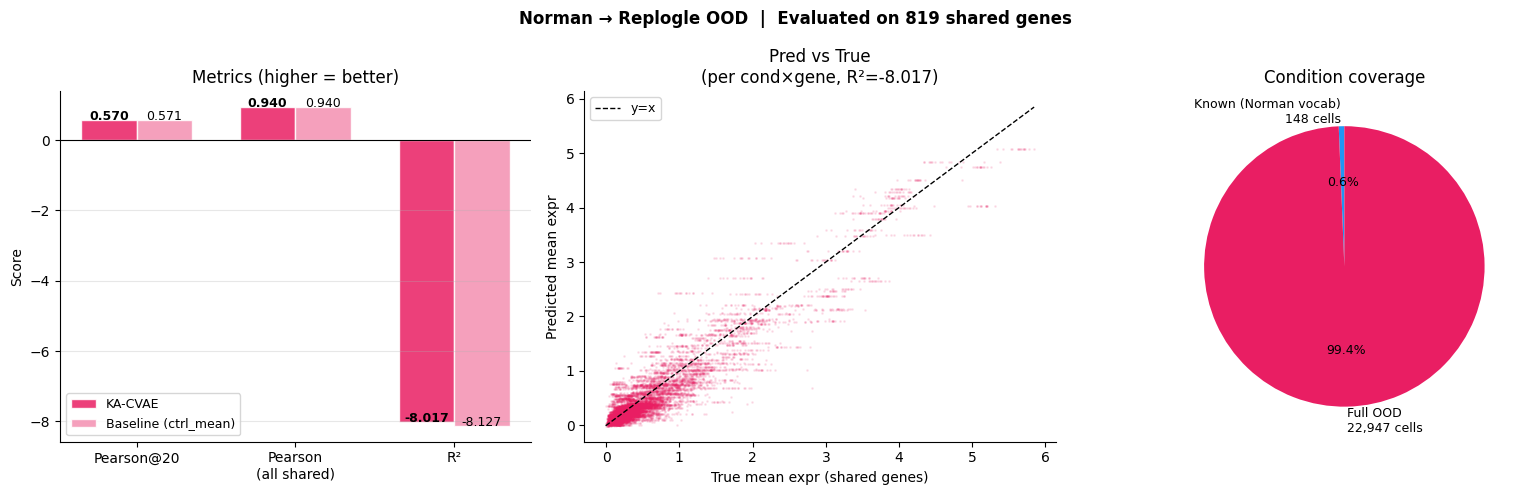

Plot saved ✓


In [31]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Norman → Replogle OOD  |  Evaluated on {n_shared} shared genes',
             fontsize=12, fontweight='bold')

# Bar: Pearson@20 and R²
metrics  = ['Pearson@20', 'Pearson\n(all shared)', 'R²']
model_v  = [p20, p_all, r2]
base_v   = [p20_base, p_all_base, r2_base]
x = np.arange(3)
w = 0.35
axes[0].bar(x-w/2, model_v, w, label='KA-CVAE', color='#E91E63', alpha=0.85, edgecolor='white')
axes[0].bar(x+w/2, base_v,  w, label='Baseline (ctrl_mean)', color='#F48FB1', alpha=0.85, edgecolor='white')
for i, (mv, bv) in enumerate(zip(model_v, base_v)):
    axes[0].text(i-w/2, mv+0.005, f'{mv:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i+w/2, bv+0.005, f'{bv:.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score'); axes[0].set_title('Metrics (higher = better)')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].spines[['top','right']].set_visible(False)

# Scatter: mean predicted vs mean true (across conditions, top-20 DE genes)
flat_pred = pred_cond_mean.flatten()
flat_true = true_cond_mean.flatten()
axes[1].scatter(flat_true, flat_pred, alpha=0.1, s=1, color='#E91E63')
lim = [min(flat_true.min(), flat_pred.min()), max(flat_true.max(), flat_pred.max())]
axes[1].plot(lim, lim, 'k--', lw=1, label='y=x')
axes[1].set_xlabel('True mean expr (shared genes)'); axes[1].set_ylabel('Predicted mean expr')
axes[1].set_title(f'Pred vs True\n(per cond×gene, R²={r2:.3f})')
axes[1].legend(fontsize=9); axes[1].spines[['top','right']].set_visible(False)

# Pie: known vs unknown conditions
axes[2].pie([n_known, n_unknown],
            labels=[f'Known (Norman vocab)\n{n_known:,} cells',
                    f'Full OOD\n{n_unknown:,} cells'],
            colors=['#2196F3','#E91E63'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':9})
axes[2].set_title('Condition coverage')

plt.tight_layout()
plt.savefig(f'{OOD_OUTPUT}/ood_replogle_results_fixed.png', dpi=130, bbox_inches='tight')
plt.show()
print('Plot saved ✓')
